Name: Priyadharshini B

Roll no: 24BAD093

**Recommendation Systems using Matrix Factorization**
(SVD & NMF)


**Scenario 1: MATRIX FACTORIZATION USING SVD**

   user_id  movie_id  rating
0        1       101       5
1        1       102       3
2        1       103       4
3        2       101       4
4        2       104       5

User-Item Matrix:
 movie_id  101  102  103  104
user_id                     
1         5.0  3.0  4.0  NaN
2         4.0  NaN  NaN  5.0
3         NaN  2.0  5.0  NaN
4         3.0  NaN  NaN  4.0
5         NaN  5.0  4.0  3.0

Predicted Ratings:
 movie_id  101  102  103  104
user_id                     
1         5.0  3.0  4.0  4.0
2         4.0  4.5  4.5  5.0
3         3.5  2.0  5.0  3.5
4         3.0  3.5  3.5  4.0
5         4.0  5.0  4.0  3.0

Top Recommendations for User 1:
 movie_id
104    4.0
Name: 1, dtype: float64

RMSE: 4.2518304777254294e-16

MAE: 2.590520390792032e-16


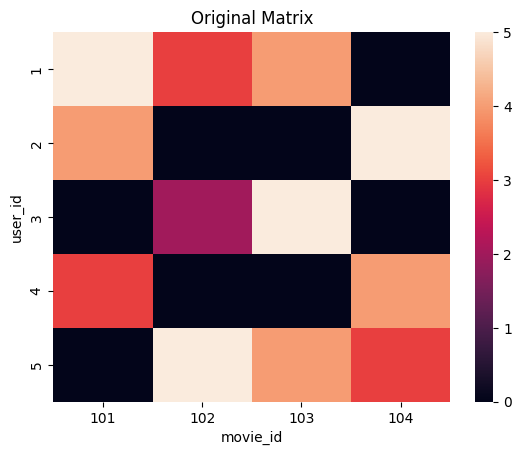

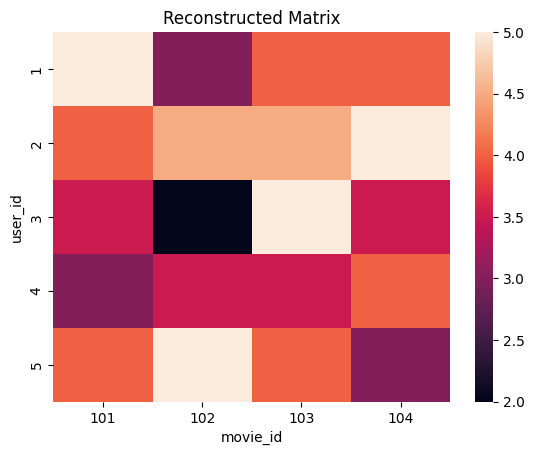

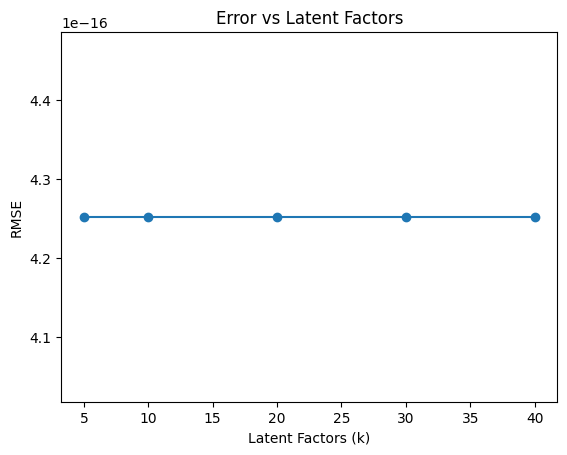

In [2]:
#Roll No: 24BAD093

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from numpy.linalg import svd


# 2. Load Dataset
# For MovieLens:
# data = pd.read_csv("u.data", sep="\t", names=["user_id", "movie_id", "rating", "timestamp"])

# For sample dataset (if using):
data = pd.read_csv("/content/sample_movielens_dataset.csv")

print(data.head())

# 3. Data Preprocessing
data = data.drop("timestamp", axis=1, errors='ignore')

# 4. Create User-Item Matrix
user_item_matrix = data.pivot(index="user_id", columns="movie_id", values="rating")

print("\nUser-Item Matrix:\n", user_item_matrix.head())

# 5. Normalize (Mean Centering)
user_means = user_item_matrix.mean(axis=1)
matrix_norm = user_item_matrix.sub(user_means, axis=0)

# Fill NaN with 0
matrix_norm = matrix_norm.fillna(0)

# 6. Apply SVD
U, sigma, Vt = svd(matrix_norm, full_matrices=False)

# 7. Reduce Dimensions (k)
k = 20  # Change this for analysis

U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

# 8. Reconstruct Matrix
matrix_reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)

# Add user means back
matrix_reconstructed = matrix_reconstructed + user_means.values.reshape(-1, 1)

# Convert to DataFrame
reconstructed_df = pd.DataFrame(matrix_reconstructed,
                               index=user_item_matrix.index,
                               columns=user_item_matrix.columns)

# 9. Predict Missing Ratings

predicted_ratings = reconstructed_df

print("\nPredicted Ratings:\n", predicted_ratings.head())

# 10. Top-N Recommendations

def recommend_movies(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id]
    predictions = predicted_ratings.loc[user_id]

    # Remove already rated movies
    unseen = user_ratings[user_ratings.isna()].index
    recommendations = predictions[unseen].sort_values(ascending=False).head(n)

    return recommendations

print("\nTop Recommendations for User 1:\n", recommend_movies(1, 5))

# Evaluation Metrics

# Only compare known ratings
actual = user_item_matrix.values.flatten()
predicted = predicted_ratings.values.flatten()

# Remove NaN
mask = ~np.isnan(actual)
actual = actual[mask]
predicted = predicted[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nRMSE:", rmse)
print("\nMAE:", mae)

# Visualization

# Heatmap: Original Matrix
plt.figure()
sns.heatmap(user_item_matrix.fillna(0))
plt.title("Original Matrix")
plt.show()

# Heatmap: Reconstructed Matrix
plt.figure()
sns.heatmap(reconstructed_df)
plt.title("Reconstructed Matrix")
plt.show()

# Error vs Latent Factors
k_values = [5, 10, 20, 30, 40]
rmse_list = []

for k in k_values:
    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    recon = np.dot(np.dot(U_k, sigma_k), Vt_k)
    recon = recon + user_means.values.reshape(-1, 1)

    pred = recon.flatten()
    pred = pred[mask]

    rmse_k = np.sqrt(mean_squared_error(actual, pred))
    rmse_list.append(rmse_k)

plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

**SCENARIO 2 – MATRIX FACTORIZATION USING NM**F

   user_id  movie_id  rating
0        1       101       5
1        1       102       3
2        1       103       4
3        2       101       4
4        2       104       5

User Feature Matrix (W):
 [[0.         2.34402863 3.72455486]
 [3.41542349 0.         2.97770225]
 [0.         2.44129823 0.00482423]
 [2.73344282 0.         2.23318434]
 [2.13269728 2.86388872 0.        ]]

Item Feature Matrix (H):
 [[6.29846609e-04 1.15283777e-01 0.00000000e+00 1.44535552e+00]
 [0.00000000e+00 1.29882222e+00 1.67653223e+00 0.00000000e+00]
 [1.34251885e+00 0.00000000e+00 9.58273489e-03 1.07826226e-02]]

Reconstructed Matrix:
 movie_id       101       102       103       104
user_id                                         
1         5.000285  3.044476  3.965531  0.040160
2         3.999773  0.393743  0.028535  4.968609
3         0.006477  3.170812  4.092961  0.000052
4         2.999814  0.315122  0.021400  3.974876
5         0.001343  3.965548  4.801402  3.082506

Top Recommendations for User 1:
 

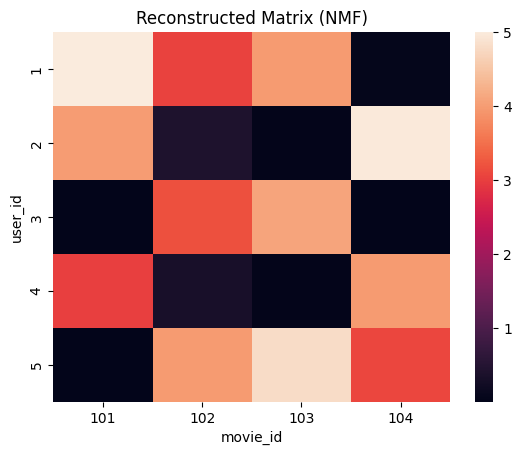

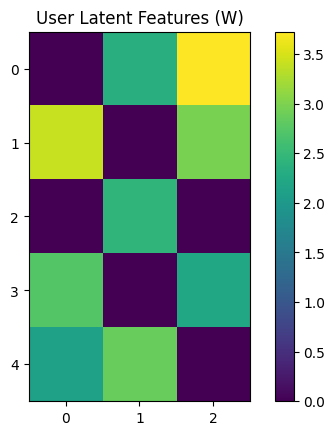

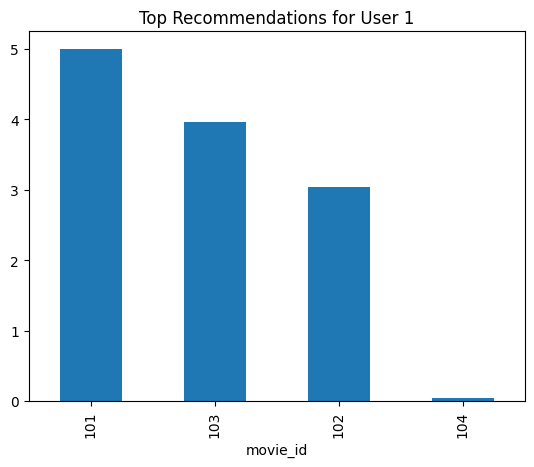

In [3]:
#Roll no: 24BAD093

# MATRIX FACTORIZATION USING NMF

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# 2. Load Dataset
data = pd.read_csv("/content/sample_movielens_dataset.csv")

print(data.head())

# 3. Create User-Item Matrix
user_item = data.pivot(index="user_id", columns="movie_id", values="rating")

# 4. Handle Missing Values
# Fill missing with 0 (NMF requires non-negative values)
user_item_filled = user_item.fillna(0)

# 5. Apply NMF Model
k = 3  # latent factors
nmf_model = NMF(n_components=k, init='random', random_state=42)

# 6. Factorization
W = nmf_model.fit_transform(user_item_filled)   # User-feature matrix
H = nmf_model.components_                      # Item-feature matrix

print("\nUser Feature Matrix (W):\n", W)
print("\nItem Feature Matrix (H):\n", H)

# 7. Reconstruct Matrix
reconstructed = np.dot(W, H)

reconstructed_df = pd.DataFrame(reconstructed,
                                index=user_item.index,
                                columns=user_item.columns)

print("\nReconstructed Matrix:\n", reconstructed_df)

# 8. Predict Missing Values
predicted_ratings = reconstructed_df

# 9. Top-N Recommendations
def recommend_movies(user_id, n=3):
    user_ratings = user_item.loc[user_id]
    predictions = predicted_ratings.loc[user_id]

    unseen_movies = user_ratings[user_ratings.isna()].index
    recommendations = predictions[unseen_movies].sort_values(ascending=False).head(n)

    return recommendations

print("\nTop Recommendations for User 1:\n", recommend_movies(1))

# 10. RMSE Calculation
actual = user_item.values.flatten()
predicted = predicted_ratings.values.flatten()

mask = ~np.isnan(actual)
actual = actual[mask]
predicted = predicted[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("\nRMSE:", rmse)

# 11. Precision@K and Recall@K
def precision_recall_at_k(user_id, k=3, threshold=3.5):
    actual_ratings = user_item.loc[user_id]
    predicted = predicted_ratings.loc[user_id]

    # Relevant items
    relevant = actual_ratings[actual_ratings >= threshold].index

    # Top K recommended
    recommended = predicted.sort_values(ascending=False).head(k).index

    # Intersection
    relevant_and_recommended = set(recommended).intersection(set(relevant))

    precision = len(relevant_and_recommended) / k
    recall = len(relevant_and_recommended) / len(relevant) if len(relevant) > 0 else 0

    return precision, recall

p, r = precision_recall_at_k(1, k=3)
print("\nPrecision@K:", p)
print("Recall@K:", r)

# 12. Visualization
# Heatmap of reconstructed matrix
import seaborn as sns

plt.figure()
sns.heatmap(reconstructed_df)
plt.title("Reconstructed Matrix (NMF)")
plt.show()

# Latent feature visualization
plt.figure()
plt.imshow(W)
plt.title("User Latent Features (W)")
plt.colorbar()
plt.show()

# Recommendation ranking chart
user_id = 1
predicted_ratings.loc[user_id].sort_values(ascending=False).plot(kind='bar')
plt.title("Top Recommendations for User 1")
plt.show()